## MArket Breath
#### Strategy with new technical indicators

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from QuantLib import standar_norm as stdnorm

#Importamos datos de IPC
ipc_df = pd.read_csv('ipc_data.csv')
ipc_df['Date'] = pd.to_datetime(ipc_df['Date'])
ipc_df.set_index('Date', inplace=True)
ipc_df = ipc_df.rename(columns={'Promotora Infraestructura': 'Pinfra'})
# Mostrar las primeras filas y la información general del DataFrame
#ipc_df.info(), ipc_df.head()

In [2]:
filtered_df = ipc_df.dropna()
# Calcular retornos logarítmicos
log_returns = np.log(filtered_df / filtered_df.shift(1)).dropna()
log_returns.head(5)
#filtered_df

,Alfa,Alsea,América Móvil,Arca Continental,BMV,Banco del Bajío,Banorte,Becle,Bimbo,Cementos Chihuahua,...,Liverpool,Megacable,Orbia,Pinfra,Quálitas,Regional,Televisa,Vesta,Volaris,Walmart México
Date,,,,,,,,,,,,,,,,,,,,,
2019-04-12 05:00:00,-0.004045,0.007137,0.000000,-0.010837,-0.011154,0.006273,0.029212,-0.000345,-0.009390,0.000493,...,-0.004511,0.013979,-0.013429,0.002367,-0.022691,0.003083,-0.020507,-0.004261,-0.020155,0.002215
2019-04-15 05:00:00,0.008073,0.004213,0.000000,-0.003512,-0.001746,-0.003508,-0.019351,-0.001383,-0.006976,0.036927,...,0.005177,-0.018025,-0.026067,-0.002583,0.011518,0.000000,-0.016105,-0.003208,0.010128,0.008079
2019-04-16 05:00:00,0.023834,0.007056,0.000000,0.008709,0.000499,0.013463,-0.005003,0.016813,0.011434,0.007469,...,-0.000500,0.002626,0.025631,0.011625,0.001080,0.012729,0.024061,0.000357,-0.009530,0.014525
2019-04-17 05:00:00,-0.000491,-0.014609,0.020340,0.008728,0.016091,0.000990,0.043990,-0.003067,0.001482,0.010495,...,-0.002420,-0.005369,-0.001091,0.016533,0.006025,0.012375,0.007402,0.006049,-0.000599,-0.000361
2019-04-22 05:00:00,-0.011852,-0.013694,0.043985,-0.004308,0.012204,-0.004712,0.001951,-0.007193,0.000000,0.006596,...,0.005664,0.005260,0.007831,-0.024607,0.007055,0.008390,-0.023882,0.033488,0.010128,0.017516


In [3]:
# Suma de retornos diarios para cada fecha
daily_total_returns = log_returns.sum(axis=1)
# Porcentaje de empresas con retorno positivo cada día
daily_positive_percent = (log_returns > 0).mean(axis=1) * 100
ipc_breadth_df = pd.DataFrame({
    'Daily Total Returns': daily_total_returns,
    'Daily Positive Percent': daily_positive_percent
})
# Mostrar las primeras filas del DataFrame de amplitud
ipc_breadth_df.index = pd.to_datetime(ipc_breadth_df.index, utc= True)
# Mostrar las primeras filas y la información general del DataFrame de amplitud
ipc_breadth_df.head()

,Daily Total Returns,Daily Positive Percent
Date,,
2019-04-12 05:00:00+00:00,-0.089011,36.111111
2019-04-15 05:00:00+00:00,-0.023669,47.222222
2019-04-16 05:00:00+00:00,0.273839,80.555556
2019-04-17 05:00:00+00:00,0.309512,66.666667
2019-04-22 05:00:00+00:00,-0.040831,36.111111


In [116]:
dpp = ipc_breadth_df[['Daily Positive Percent']].copy()
dtr = ipc_breadth_df[['Daily Total Returns']].copy()
type(dpp.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [117]:
dtr

,Daily Total Returns
Date,
2019-04-12 05:00:00+00:00,-0.077602
2019-04-15 05:00:00+00:00,-0.001130
2019-04-16 05:00:00+00:00,0.229465
2019-04-17 05:00:00+00:00,0.319573
2019-04-22 05:00:00+00:00,-0.026601
...,...
2025-02-24 06:00:00+00:00,-0.017647
2025-02-25 06:00:00+00:00,-0.601260
2025-02-26 06:00:00+00:00,0.021350


In [118]:
import matplotlib.cm as cm
dataframe = ipc_breadth_df['Daily Positive Percent']
norm = plt.Normalize(dataframe.min(), dataframe.max())
colors = cm.Spectral(norm(dataframe))
colors

array([[0.99638601, 0.88796617, 0.56109189, 1.        ],
       [0.99807766, 0.99923106, 0.74602076, 1.        ],
       [0.30403691, 0.65374856, 0.69134948, 1.        ],
       ...,
       [0.83844675, 0.9349481 , 0.60899654, 1.        ],
       [0.82260669, 0.22906574, 0.30680507, 1.        ],
       [0.90580546, 0.96232218, 0.60207612, 1.        ]])

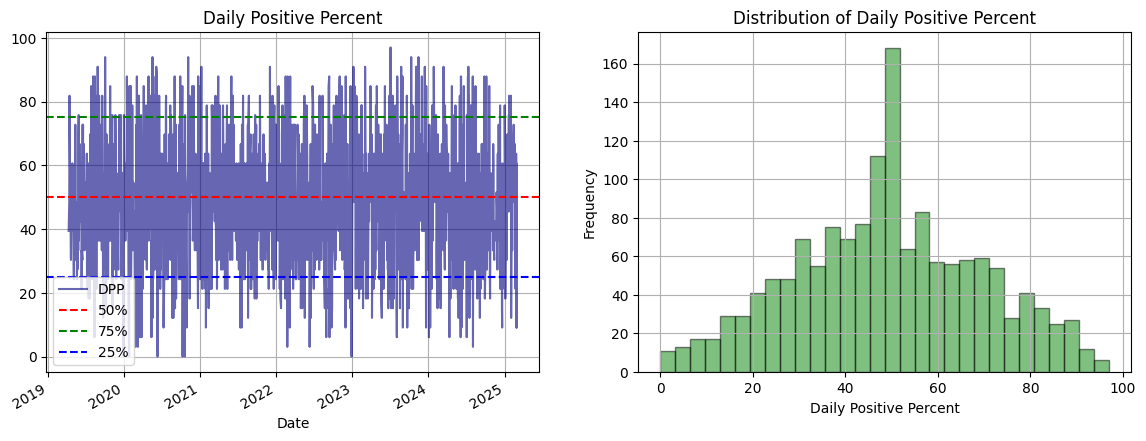

C:\Users\marti\AppData\Local\Temp\ipykernel_22348\2203246463.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


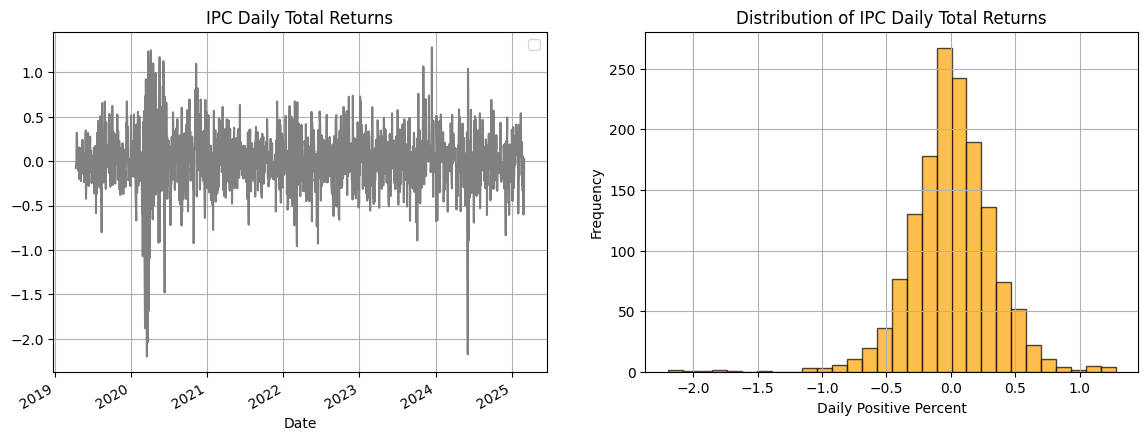

In [119]:
import matplotlib.cm as cm
dataframe = ipc_breadth_df['Daily Positive Percent']
norm = plt.Normalize(dataframe.min(), dataframe.max())
colors = cm.Spectral(norm(dataframe))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
ipc_breadth_df['Daily Positive Percent'].plot(title='Daily Positive Percent',color='navy', alpha=0.6, label='DPP')
plt.axhline(y=50, color='r', linestyle='--', label='50%')
plt.axhline(y=75, color='g', linestyle='--', label='75%')
plt.axhline(y=25, color='b', linestyle='--', label='25%')
plt.legend()
plt.xlabel('Date')
plt.grid()
#plt.show()

# Graficar la distribución de los porcentajes diarios positivos
plt.subplot(1, 2, 2)
#plt.figure(figsize=(14, 7))
plt.hist(ipc_breadth_df['Daily Positive Percent'], bins=30, alpha=0.5, edgecolor='black', color='green')
plt.title('Distribution of Daily Positive Percent')
plt.xlabel('Daily Positive Percent')
plt.ylabel('Frequency') 
plt.grid()
plt.show()

plt.figure(figsize=(14, 5))
# Graficar los retornos diarios totales
plt.subplot(1, 2, 1)
#plt.figure(figsize=(10, 7))
daily_total_returns.plot(title='IPC Daily Total Returns', color='gray', alpha=1)#, secondary_y=True)
plt.xlabel('Date')
plt.legend()
plt.grid()
#plt.show()

plt.subplot(1, 2, 2)
plt.hist(ipc_breadth_df['Daily Total Returns'], bins=30, alpha=0.7, edgecolor='black', color='orange')
plt.title('Distribution of IPC Daily Total Returns')
plt.xlabel('Daily Positive Percent')
plt.ylabel('Frequency') 
plt.grid()
plt.show()

#### Comparación con indice IPC

-1 Emparejamos las fechas de cada DF

In [120]:
ipci_df = pd.read_csv('SData_^MXX_1991-2024.csv')
ipci_df['Date'] = pd.to_datetime(ipci_df['Date'])#, utc=True)
ipci_df.set_index('Date', inplace=True)
ipci_df = ipci_df[['Close']]
ipci_df['2019-04-12':'2019-04-22']

,Close
Date,
2019-04-12,44686.058594
2019-04-15,44625.781250
2019-04-16,45009.359375
2019-04-17,45525.289062
2019-04-22,45381.218750


Asumiendo que `dtr` y `dpp` son objetos de tipo DataFrame de la biblioteca pandas.
1. **`dpp.index = dtr.index.tz_localize(None)`**:
   - Esta línea toma el índice del DataFrame `dtr`, que presumiblemente tiene una zona horaria asignada (es decir, es un índice de tipo `DatetimeIndex` con información de zona horaria), y utiliza el método `tz_localize(None)` para eliminar esa información de zona horaria. 
   - El resultado es un índice de tipo `DatetimeIndex` que contiene las mismas fechas y horas, pero sin la información de la zona horaria. Luego, este nuevo índice sin zona horaria se asigna al índice del DataFrame `dpp`.

2. **`dpp.index = dpp.index.normalize()`**:
   - Esta línea aplica el método `normalize()` al índice del DataFrame `dpp`. 
   - El método `normalize()` convierte cada fecha y hora en el índice a la medianoche de ese día, es decir, establece la hora a `00:00:00` para cada fecha. Esto es útil si deseas trabajar solo con la fecha sin preocuparte por la hora.

En resumen, estas dos líneas de código están manipulando el índice de un DataFrame para eliminar la información de zona horaria y luego normalizar las fechas a la medianoche.

In [121]:
def del_tz(df):
    """ Elimina la zona horaria de un DataFrame con índice de fecha y hora."""
    df.index = df.index.tz_localize(None)
    df.index = df.index.normalize()

def common_dates(df1, df2):
    """Encuentra las fechas comunes entre dos DataFrames y los empareja."""
    common_dates = df1.index.intersection(df2.index)
    df1 = df1.loc[common_dates]
    df2 = df2.loc[common_dates]
    return df1, df2

In [122]:
# Eliminar la zona horaria de los DataFrames
del_tz(dpp)
del_tz(dtr)
# Alinear los DataFrames por las fechas comunes y quitar TimeZones
dpp, ipci_df = common_dates(dpp, ipci_df)
dtr, ipci_df = common_dates(dtr, ipci_df)
# Verificar que los índices de los DataFrames son iguales
ipci_df.index == dpp.index

array([ True,  True,  True, ...,  True,  True,  True])

In [123]:
dpp

,Daily Positive Percent
Date,
2019-04-12,39.393939
2019-04-15,48.484848
2019-04-16,81.818182
2019-04-17,69.696970
2019-04-22,36.363636
...,...
2024-08-29,63.636364
2024-08-30,30.303030
2024-09-02,57.575758


In [124]:
dtr

,Daily Total Returns
Date,
2019-04-12,-0.077602
2019-04-15,-0.001130
2019-04-16,0.229465
2019-04-17,0.319573
2019-04-22,-0.026601
...,...
2024-08-29,0.244721
2024-08-30,-0.101030
2024-09-02,0.181482


In [125]:
ipci_df

,Close
Date,
2019-04-12,44686.058594
2019-04-15,44625.781250
2019-04-16,45009.359375
2019-04-17,45525.289062
2019-04-22,45381.218750
...,...
2024-08-29,53138.960938
2024-08-30,52913.500000
2024-09-02,52493.378906


c:\Users\marti\Documents\python\.venv\lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


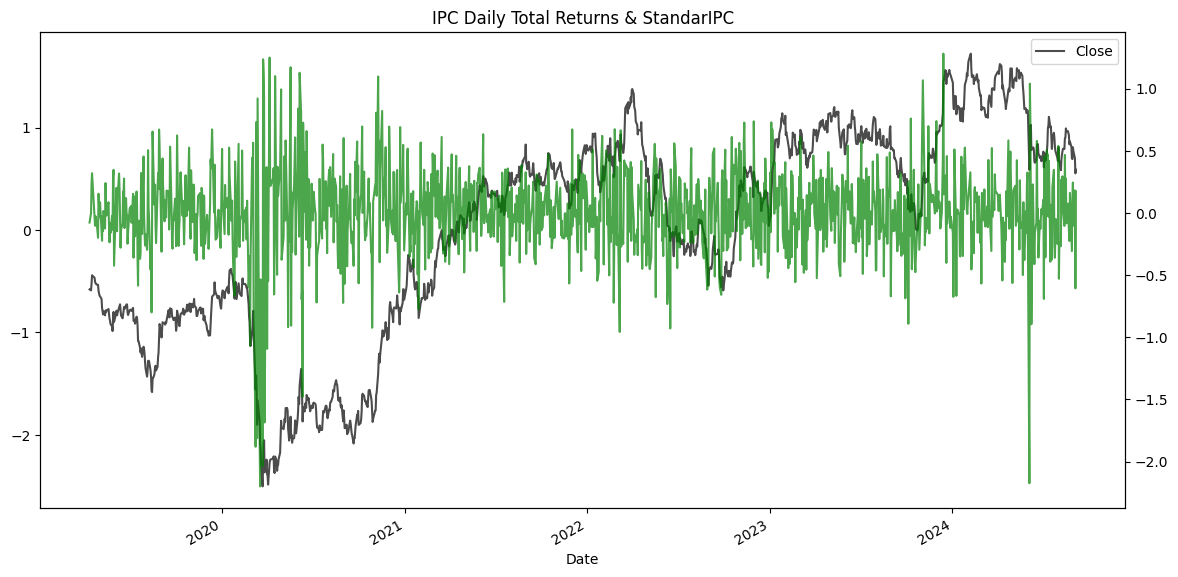

In [126]:
# Calcular los retornos estandarizados del IPC
ipci_stddf = stdnorm(ipci_df)
#ipci_df = ipci_df.reindex(standardized_returns.index).dropna()
# Unir los datos del IPC con los datos proyectados
#plt.figure(figsize=(14, 7))
#plt.plot( dpp, label='Daily Positive Percent', color='blue')
#plt.plot( ipci_stddf, label='Standardized IPC Returns', color='orange')
ipci_stddf.plot(figsize=(14, 7), title='IPC Daily Total Returns & StandarIPC', color= 'black',alpha=0.7)
#dpp['Daily Positive Percent'].plot(figsize=(14, 7), title='IPC Daily Positive Percent', secondary_y=True, color='purple', alpha=0.7)
dtr['Daily Total Returns'].plot(figsize=(14, 7), secondary_y=True, alpha=0.7, color='green')
plt.xlabel('Date')
plt.show()

In [127]:
for item in dpp.items():
    print(item)

('Daily Positive Percent', Date
2019-04-12    39.393939
2019-04-15    48.484848
2019-04-16    81.818182
2019-04-17    69.696970
2019-04-22    36.363636
                ...    
2024-08-29    63.636364
2024-08-30    30.303030
2024-09-02    57.575758
2024-09-03    12.121212
2024-09-04    57.575758
Name: Daily Positive Percent, Length: 1361, dtype: float64)


In [128]:
type(ipci_df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [129]:
for date, indicator in dpp['Daily Positive Percent'].items():
    # Asegurarse de que la fecha esté en el mismo formato que el índice de ipci_df   
    price = ipci_df.loc[date, 'Close']# if date in ipci_df.index else np.nan
    print(f"Processing date: {date}, Indicator: {indicator:.2f}, Price: {price:.2f}")

Processing date: 2019-04-12 00:00:00, Indicator: 39.39, Price: 44686.06
Processing date: 2019-04-15 00:00:00, Indicator: 48.48, Price: 44625.78
Processing date: 2019-04-16 00:00:00, Indicator: 81.82, Price: 45009.36
Processing date: 2019-04-17 00:00:00, Indicator: 69.70, Price: 45525.29
Processing date: 2019-04-22 00:00:00, Indicator: 36.36, Price: 45381.22
Processing date: 2019-04-23 00:00:00, Indicator: 30.30, Price: 45148.32
Processing date: 2019-04-24 00:00:00, Indicator: 45.45, Price: 45045.33
Processing date: 2019-04-25 00:00:00, Indicator: 42.42, Price: 45026.68
Processing date: 2019-04-26 00:00:00, Indicator: 39.39, Price: 44974.97
Processing date: 2019-04-29 00:00:00, Indicator: 42.42, Price: 44956.73
Processing date: 2019-04-30 00:00:00, Indicator: 60.61, Price: 44597.32
Processing date: 2019-05-02 00:00:00, Indicator: 57.58, Price: 44312.43
Processing date: 2019-05-03 00:00:00, Indicator: 48.48, Price: 44277.24
Processing date: 2019-05-06 00:00:00, Indicator: 30.30, Price: 4

### Trading basado en market Breadth

In [130]:
dpp.index[-1]

Timestamp('2024-09-04 00:00:00')

In [131]:
def MarketBreadth_strategy(dpp, ipci_df, buy_threshold, sell_threshold, stoploss_pct, initial_balance=10000.0):
    """
    Simula la estrategia de trading usando los umbrales indicados.
    
    Parámetros:
      dpp: DataFrame que contiene el indicador "Daily Positive Percent" con índice de fecha.
      ipci_df: DataFrame que contiene el precio 'Close' del IPC, con índice de fecha.
      buy_threshold: Umbral para generar señal de compra.
      sell_threshold: Umbral para generar señal de venta.
      initial_balance: Balance inicial.
    
    Retorna:
      final_balance: Balance final tras aplicar la estrategia.
      trades: Lista de operaciones realizadas durante la simulación.
    """

    # Configuración de los umbrales de trading
    BUY_THRESHOLD = buy_threshold    # Porcentaje para activar compra
    SELL_THRESHOLD = sell_threshold   # Porcentaje para activar venta

    # Configuración inicial
    #initial_balance = 10000.0
    balance = initial_balance
    position = 0.0      # Por ejemplo, número de unidades (acciones, contratos, etc.)
    entry_price = None  # Precio de entrada en la posición
    trades = []         # Historial de operaciones

    # Recorremos día a día el indicador
    for date, indicator in dpp['Daily Positive Percent'].items():
        # Obtener el precio de cierre para la fecha actual
        price = ipci_df.loc[date, 'Close']
        #print(f"Processing date: {date}, Indicator: {indicator:.2f}, Price: {price:.2f}")
        '''    
        try:
            price = ipci_df.loc[date]
            print(f"Processing date: {date}, Indicator: {indicator:.2f}, Price: {price:.2f}")
        except KeyError:
            # Si para la fecha no se encuentra precio, se salta
            continue
        '''

        # Regla de entrada: Si el indicador supera el umbral de compra y no estamos en posición
        if indicator > BUY_THRESHOLD and position == 0:
            # Compramos utilizando todo el balance
            position = balance / price
            entry_price = price
            balance = 0.0
            trades.append({
                'Date': date,
                'Action': 'BUY',
                'Price': price,
                'Position': position
            })
            print(f"{date} BUY at {price:.2f}")

        # Regla de salida: Si el indicador cae por debajo del umbral de venta y tenemos posición
        elif indicator < SELL_THRESHOLD and position > 0:
            # Vendemos toda la posición
            balance = position * price
            trades.append({
                'Date': date,
                'Action': 'SELL',
                'Price': price,
                'Position': position
            })
            print(f"{date} SELL at {price:.2f}")
            position = 0.0

        # Salida por stoploss
        elif position > 0 and entry_price is not None and stoploss_pct is not None:
            loss = (price - entry_price) / entry_price
            if loss <= stoploss_pct: #-0.5<=-0.05??
                balance = position * price
                trades.append({'Date': date, 'Action': 'STOPLOSS', 'Price': price, 'Position': position})
                position = 0.0
                entry_price = None
                print(f"{date} STOPLOSS at {price:.2f} (Loss: {loss:.2%})")

    # Si existe una posición abierta al final de la serie, se cierra en el último precio disponible
    if position > 0:
        final_date = dpp.index[-1]
        final_price = ipci_df.loc[final_date, 'Close']
        balance = position * final_price
        trades.append({
            'Date': final_date,
            'Action': 'SELL',
            'Price': final_price,
            'Position': position
        })
        print(f"{final_date} SELL at {final_price:.2f} (Final position closed)")
        position = 0.0

    print("\nTrading Summary:")
    for trade in trades:
        print(trade)
    print(f"\nBalance final: {balance:.2f} (Balance Inicial: {initial_balance:.2f})")
    
    
    return balance, trades

balance, trades = MarketBreadth_strategy(dpp, ipci_df, buy_threshold=25, sell_threshold=75, stoploss_pct=None,initial_balance=10000.0)

2019-04-12 00:00:00 BUY at 44686.06
2019-04-15 00:00:00 SELL at 44625.78
2019-04-16 00:00:00 BUY at 45009.36
2019-04-17 00:00:00 SELL at 45525.29
2019-04-22 00:00:00 BUY at 45381.22
2019-04-23 00:00:00 SELL at 45148.32
2019-04-24 00:00:00 BUY at 45045.33
2019-04-25 00:00:00 SELL at 45026.68
2019-04-26 00:00:00 BUY at 44974.97
2019-04-29 00:00:00 SELL at 44956.73
2019-04-30 00:00:00 BUY at 44597.32
2019-05-02 00:00:00 SELL at 44312.43
2019-05-03 00:00:00 BUY at 44277.24
2019-05-06 00:00:00 SELL at 44116.70
2019-05-08 00:00:00 BUY at 43410.74
2019-05-09 00:00:00 SELL at 43193.36
2019-05-10 00:00:00 BUY at 43382.35
2019-05-13 00:00:00 SELL at 43142.46
2019-05-14 00:00:00 BUY at 43431.53
2019-05-15 00:00:00 SELL at 43338.82
2019-05-16 00:00:00 BUY at 43442.49
2019-05-17 00:00:00 SELL at 43445.62
2019-05-20 00:00:00 BUY at 43519.22
2019-05-21 00:00:00 SELL at 43190.10
2019-05-23 00:00:00 BUY at 42812.57
2019-05-24 00:00:00 SELL at 42617.60
2019-05-27 00:00:00 BUY at 42491.43
2019-05-28 00:0

In [132]:
ipci_df

,Close
Date,
2019-04-12,44686.058594
2019-04-15,44625.781250
2019-04-16,45009.359375
2019-04-17,45525.289062
2019-04-22,45381.218750
...,...
2024-08-29,53138.960938
2024-08-30,52913.500000
2024-09-02,52493.378906


In [133]:
def total_return(df):
    """Calcula el retorno porcentual de un DataFrame con precios."""
    return (df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0] * 100
# Calcular el retorno porcentual del IPC
ipc_return = total_return(ipci_df)

print(f"Retorno porcentual del IPC: {ipc_return:.2f}%")
# Calcular el retorno porcentual de la estrategia

Retorno porcentual del IPC: 15.95%


In [134]:
def total_return(df):
    """Calcula el retorno porcentual de un DataFrame con precios."""
    return (df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0] * 100

def trading_return(trades, initial_balance):
    """Calcula el retorno total de una estrategia de trading."""
    final_balance = initial_balance
    for trade in trades:
        if trade['Action'] == 'BUY':
            final_balance -= trade['Price'] * trade['Position']
        elif trade['Action'] == 'SELL':
            final_balance += trade['Price'] * trade['Position']
        elif trade['Action'] == 'STOPLOSS':
            final_balance += trade['Price'] * trade['Position'] 
    return final_balance

# Calcular el rendimiento total del trading
print(f"Total TradeDays: {len(ipci_df)}")
print(f"Number of trades: {len(trades)}")

holder = 10000 * (ipci_df['Close'].iloc[-1] / ipci_df['Close'].iloc[0] - 1) + 10000
print(f"Total Trading Return: {balance:.2f} (Holder Return: {holder:.2f})")

initial_balance = 10000
# Calcular el retorno total de la estrategia de trading
final_balance = trading_return(trades, initial_balance)

# Calcular el retorno porcentual de la estrategia de trading
trading_return_percentage = ((final_balance - initial_balance) / initial_balance )* 100
trading_lreturn_percentage = np.log(final_balance/ initial_balance) * 100

print(f"Initial Balance: {initial_balance:.2f}\nFinal Balance: {final_balance:.2f} ")
print(f"Trading Return Percentage: {trading_return_percentage:.2f}%")
print(f"Rendimiento Anual: {trading_return_percentage/4:.2f}%")
# Calcular el retorno porcentual del IPC
ipc_return = total_return(ipci_df)
print(f"Retorno porcentual del IPC durante el periodo: {ipc_return:.2f}%")

Total TradeDays: 1361
Number of trades: 1168
Total Trading Return: 14444.48 (Holder Return: 11594.53)
Initial Balance: 10000.00
Final Balance: 14444.48 
Trading Return Percentage: 44.44%
Rendimiento Anual: 11.11%
Retorno porcentual del IPC durante el periodo: 15.95%


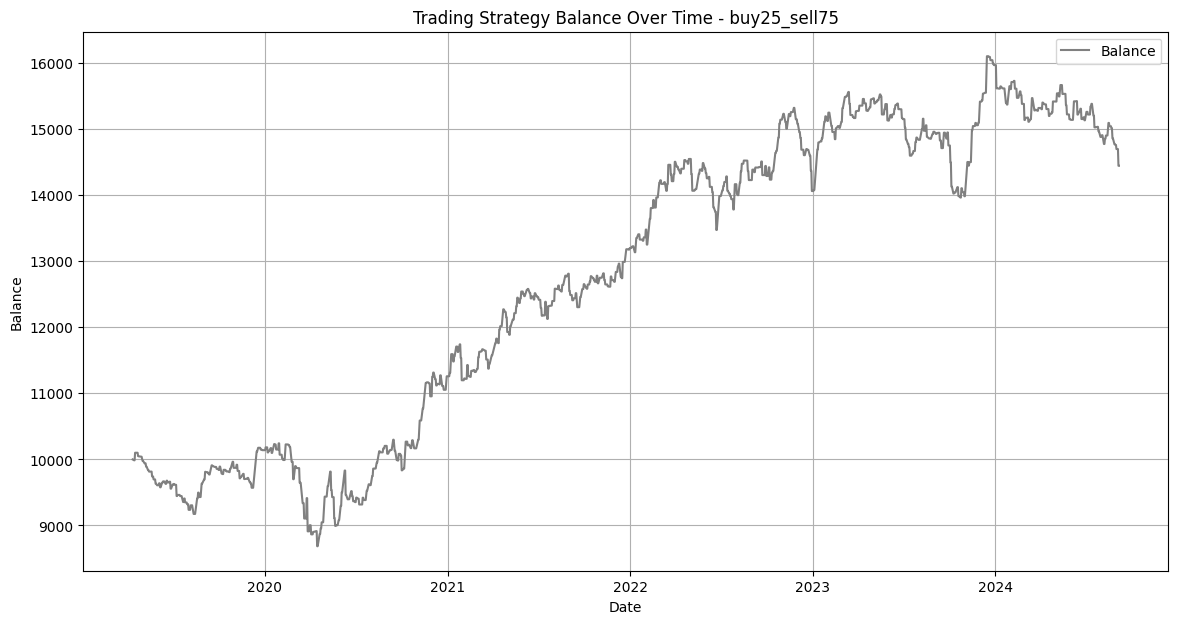

In [167]:
# Graficar el balance a lo largo del tiempo
trades_df = pd.DataFrame(trades)
trades_df['Balance'] =  trades_df['Price'] * trades_df['Position'].fillna(0)
plt.figure(figsize=(14, 7))
plt.plot(trades_df['Date'], trades_df['Balance'], linestyle='-', color='gray', label='Balance')
#plt.axhline(y=initial_balance, color='red', linestyle='--', label='Initial Balance')
plt.title('Trading Strategy Balance Over Time - buy25_sell75')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.legend()
plt.grid()
plt.show()
# Graficar el balance a lo largo del tiempo con el IPC

In [136]:
trades_df

,Date,Action,Price,Position,Balance
0,2019-04-12,BUY,44686.058594,0.223783,10000.000000
1,2019-04-15,SELL,44625.781250,0.223783,9986.510929
2,2019-04-16,BUY,45009.359375,0.221876,9986.510929
3,2019-04-17,SELL,45525.289062,0.221876,10100.983508
4,2019-04-22,BUY,45381.218750,0.222581,10100.983508
...,...,...,...,...,...
1163,2024-08-30,SELL,52913.500000,0.277766,14697.579200
1164,2024-09-02,BUY,52493.378906,0.279989,14697.579200
1165,2024-09-03,SELL,51589.421875,0.279989,14444.480994
1166,2024-09-04,BUY,51811.371094,0.278790,14444.480994


In [137]:
balans = trades_df[['Balance']].copy()
balans_logrets = np.log(balans / balans.shift(1)).dropna()
balans_rets = ((balans - balans.shift(1))/balans.shift(1)).dropna()
#balans_rets.rename(columns={'Balance': 'Balance_Rets'}, inplace=True)
balans_rets_cero = balans_rets[balans_rets['Balance']!=0]
balans_rets_cero 
#balans_rets

,Balance
1,-1.348907e-03
3,1.146272e-02
5,-5.132045e-03
7,-4.139927e-04
9,-4.055207e-04
...,...
1159,-5.975094e-03
1161,-6.562735e-04
1162,-1.232361e-16
1163,-4.242856e-03


In [138]:
(balans_rets['Balance']!=0).mean() 

0.6066838046272494

"\n# Añadir texto con estadísticas\nplt.text(0, 70, f'Media: {media:.2f}', color='red')\nplt.text(0 + std, 60, f'SD: {std:.2f}', color='green')\nplt.text(0 + std, 50, f'SD: {std:.2f}', color='green')\nplt.show()\n"

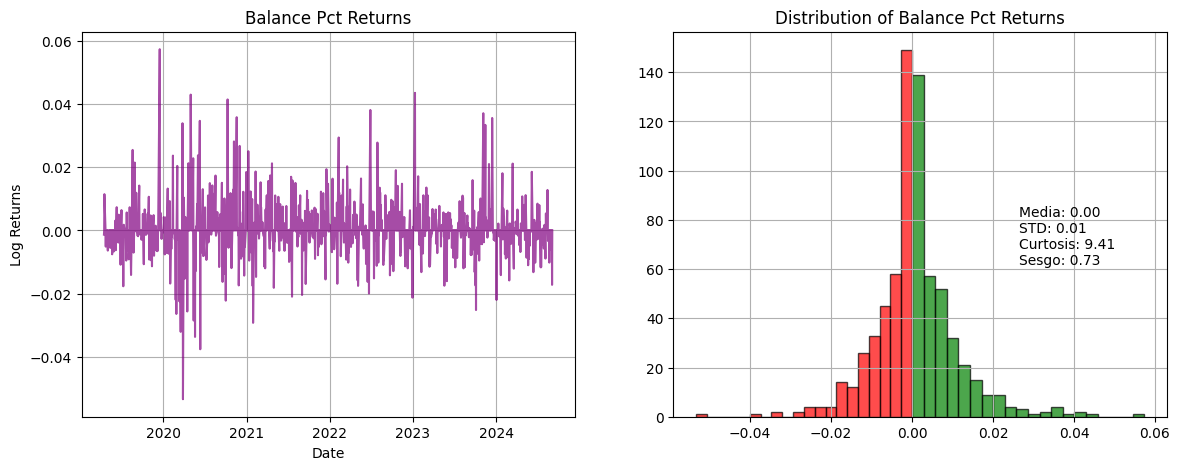

In [168]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
#balans_rets.plot( color='purple', alpha=0.7)
plt.plot(balans_rets.index, balans_rets, color='purple', alpha=0.7)
plt.title('Balance Pct Returns')
plt.xlabel('Date')  
plt.ylabel('Log Returns')
plt.grid()

#media = (balans_rets['Balance']!=0).mean()
media = balans_rets_cero['Balance'].mean()
std = balans_rets['Balance'].std()
curtosis = balans_rets['Balance'].kurtosis()
sesgo = balans_rets['Balance'].skew()
plt.subplot(1, 2, 2)
plt.hist(balans_rets[balans_rets['Balance']<0], bins=20, alpha=0.7, edgecolor='black', color='red')#,orientation='horizontal')
plt.hist(balans_rets[balans_rets['Balance']>0], bins=20, alpha=0.7, edgecolor='black', color='green')#,orientation='horizontal')
#plt.hist(balans_rets, bins=30, alpha=0.8, edgecolor='black', color='purple')
plt.title('Distribution of Balance Pct Returns')
plt.grid()

# Crear un recuadro para las estadísticas
stats_text = f'Media: {media:.2f}\nSTD: {std:.2f}\nCurtosis: {curtosis:.2f}\nSesgo: {sesgo:.2f}'
#plt.gca().add_patch(plt.Rectangle((0.02, 8), 0.025, 6, color='black', alpha=0.2, ec='black'))
# Añadir texto con estadísticas en el recuadro
plt.text(0.7, .55, stats_text, fontsize=10, ha='left', va='top', transform=plt.gca().transAxes)
'''
# Añadir texto con estadísticas
plt.text(0, 70, f'Media: {media:.2f}', color='red')
plt.text(0 + std, 60, f'SD: {std:.2f}', color='green')
plt.text(0 + std, 50, f'SD: {std:.2f}', color='green')
plt.show()
'''

In [140]:
balans_rets['Balance'].describe()

count    1.167000e+03
mean     3.473069e-04
std      8.038114e-03
min     -5.340984e-02
25%     -6.631013e-05
50%      0.000000e+00
75%      1.630726e-16
max      5.731914e-02
Name: Balance, dtype: float64

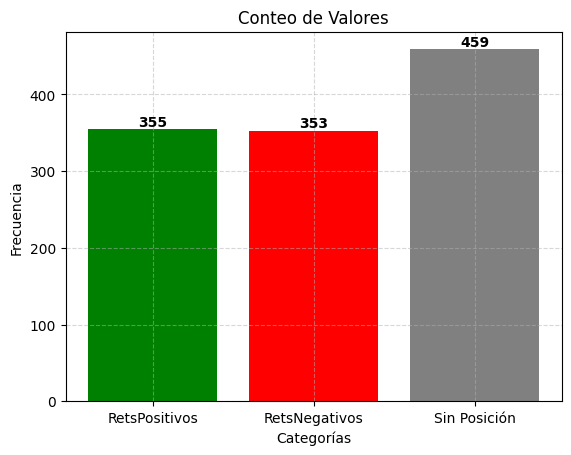

In [141]:
PosRets = (balans_logrets['Balance'] < 0).sum()# / len(balans_logrets) * 100
NegRets = (balans_logrets['Balance'] > 0).sum()# / len(balans_logrets) * 100
CeroRets = (balans_logrets['Balance'] == 0).sum()# / len(balans_logrets) * 100

conteos = [PosRets, NegRets, CeroRets]
categories = ['RetsPositivos', 'RetsNegativos', 'Sin Posición']  # Categorías de los retornos
# Porcentaje de días con retornos positivos en el balance
bars = plt.bar(categories, conteos, color=['green', 'red', 'gray'])
# Añadir texto con los valores de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, yval, ha='center', va='bottom',fontweight="bold")
plt.title('Conteo de Valores')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)  # Para que las etiquetas del eje x estén horizontales
plt.grid( linestyle='--', alpha=0.5)
plt.show()

In [142]:
def plot_trading_positions(ipci_df, trades_df):
    """
    Grafica las operaciones de compra y venta sobre el precio del IPC.
    
    Parámetros:
      ipci_df: DataFrame que contiene el precio del IPC en la columna 'Close' y el índice son fechas.
      trades: Lista de diccionarios con las operaciones. Cada diccionario debe tener las llaves:
              'Date', 'Action' (con valores 'BUY' o 'SELL') y 'Price'.
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # Convertir la lista de trades en DataFrame
    #trades_df = pd.DataFrame(trades)
    #trades_df['Date'] = pd.to_datetime(trades_df['Date'])  # Asegurar que 'Date' sea datetime

    plt.figure(figsize=(12, 6))
    plt.plot(ipci_df.index, ipci_df['Close'], label='Precio IPC', color='blue', alpha=0.7)

    # Separar operaciones de compra y venta
    buys = trades_df[trades_df['Action'] == 'BUY']
    sells = trades_df[trades_df['Action'] == 'SELL']
    stoplosses = trades_df[trades_df['Action'] == 'STOPLOSS']

    # Graficar operaciones de compra (triángulo hacia arriba)
    if not buys.empty:
        plt.scatter(buys.index, buys['Price'], marker='^', color='green', s=50, label='Compra')
    # Graficar operaciones de venta (triángulo hacia abajo)
    if not sells.empty:
        plt.scatter(sells.index, sells['Price'], marker='v', color='red', s=50, label='Venta')
    # Graficar operaciones de stoploss (cruz)
    if not stoplosses.empty:
        plt.scatter(stoplosses.index, stoplosses['Price'], marker='x', color='black', s=50, label='Stoploss')

    plt.title("Posiciones de Trading sobre el IPC")
    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.legend()
    plt.grid(True)
    plt.show()

In [143]:
def plot_trading_positionsb(trades_df):
    """
    Grafica las operaciones de compra y venta sobre el precio del IPC.
    
    Parámetros:
      ipci_df: DataFrame que contiene el precio del IPC en la columna 'Close' y el índice son fechas.
      trades: Lista de diccionarios con las operaciones. Cada diccionario debe tener las llaves:
              'Date', 'Action' (con valores 'BUY' o 'SELL') y 'Price'.
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # Convertir la lista de trades en DataFrame
    #trades_df = pd.DataFrame(trades)
    #trades_df['Date'] = pd.to_datetime(trades_df['Date'])  # Asegurar que 'Date' sea datetime

    plt.figure(figsize=(12, 6))
    plt.plot(trades_df.index, trades_df['Balance'], label='Balance', color='blue', alpha=0.7)

    # Separar operaciones de compra y venta
    buys = trades_df[trades_df['Action'] == 'BUY']
    sells = trades_df[trades_df['Action'] == 'SELL']
    stoplosses = trades_df[trades_df['Action'] == 'STOPLOSS']

    # Graficar operaciones de compra (triángulo hacia arriba)
    if not buys.empty:
        plt.scatter(buys.index, buys['Price']*buys['Position'], marker='^', color='green', s=50, label='Compra')
    # Graficar operaciones de venta (triángulo hacia abajo)
    if not sells.empty:
        plt.scatter(sells.index, sells['Price']*sells['Position'], marker='v', color='red', s=50, label='Venta')
        # Graficar operaciones de stoploss (cruz)
    if not stoplosses.empty:
        plt.scatter(stoplosses.index, stoplosses['Price']*stoplosses['Position'], marker='x', color='black', s=50, label='Stoploss')
        
    plt.title("Posiciones de Trading sobre el Balance")
    plt.xlabel("Fecha")
    plt.ylabel("Balance")
    plt.legend()
    plt.grid(True)
    plt.show()
    #return buys, sells

In [144]:
trades_df['Date'] = pd.to_datetime(trades_df['Date'])
trades_df.set_index('Date', inplace=True)
trades_df

,Action,Price,Position,Balance
Date,,,,
2019-04-12,BUY,44686.058594,0.223783,10000.000000
2019-04-15,SELL,44625.781250,0.223783,9986.510929
2019-04-16,BUY,45009.359375,0.221876,9986.510929
2019-04-17,SELL,45525.289062,0.221876,10100.983508
2019-04-22,BUY,45381.218750,0.222581,10100.983508
...,...,...,...,...
2024-08-30,SELL,52913.500000,0.277766,14697.579200
2024-09-02,BUY,52493.378906,0.279989,14697.579200
2024-09-03,SELL,51589.421875,0.279989,14444.480994


In [145]:
trades_df['2024-03-29':'2024-09-04']

,Action,Price,Position,Balance
Date,,,,
2024-04-01,BUY,57653.230469,0.265720,15319.623912
2024-04-02,SELL,57581.808594,0.265720,15300.645682
2024-04-03,BUY,57503.390625,0.266082,15300.645682
2024-04-04,SELL,57882.761719,0.266082,15401.589690
2024-04-05,BUY,58092.441406,0.265122,15401.589690
...,...,...,...,...
2024-08-30,SELL,52913.500000,0.277766,14697.579200
2024-09-02,BUY,52493.378906,0.279989,14697.579200
2024-09-03,SELL,51589.421875,0.279989,14444.480994


In [146]:
filter_ipci = ipci_df['2021-01-20':'2021-04-04']
filter_ipci

,Close
Date,
2021-01-20,45125.710938
2021-01-21,44810.210938
2021-01-22,44683.550781
2021-01-25,45126.511719
2021-01-26,45053.558594
2021-01-27,44262.011719
2021-01-28,44280.730469
2021-01-29,42985.730469
2021-02-02,43848.921875


In [147]:
#trades_df.set_index('Date', inplace=True)
filter_trades=trades_df['2021-01-20':'2021-04-04']
filter_trades

,Action,Price,Position,Balance
Date,,,,
2021-01-20,BUY,45125.710938,0.259454,11708.056383
2021-01-21,SELL,44810.210938,0.259454,11626.198575
2021-01-22,BUY,44683.550781,0.260190,11626.198575
2021-01-25,SELL,45126.511719,0.260190,11741.452437
2021-01-26,BUY,45053.558594,0.260611,11741.452437
2021-01-27,SELL,44262.011719,0.260611,11535.166624
2021-01-28,BUY,44280.730469,0.260501,11535.166624
2021-01-29,SELL,42985.730469,0.260501,11197.818061
2021-02-02,BUY,43848.921875,0.255373,11197.818061


In [148]:
trades_df

,Action,Price,Position,Balance
Date,,,,
2019-04-12,BUY,44686.058594,0.223783,10000.000000
2019-04-15,SELL,44625.781250,0.223783,9986.510929
2019-04-16,BUY,45009.359375,0.221876,9986.510929
2019-04-17,SELL,45525.289062,0.221876,10100.983508
2019-04-22,BUY,45381.218750,0.222581,10100.983508
...,...,...,...,...
2024-08-30,SELL,52913.500000,0.277766,14697.579200
2024-09-02,BUY,52493.378906,0.279989,14697.579200
2024-09-03,SELL,51589.421875,0.279989,14444.480994


In [149]:
ipci_df

,Close
Date,
2019-04-12,44686.058594
2019-04-15,44625.781250
2019-04-16,45009.359375
2019-04-17,45525.289062
2019-04-22,45381.218750
...,...
2024-08-29,53138.960938
2024-08-30,52913.500000
2024-09-02,52493.378906


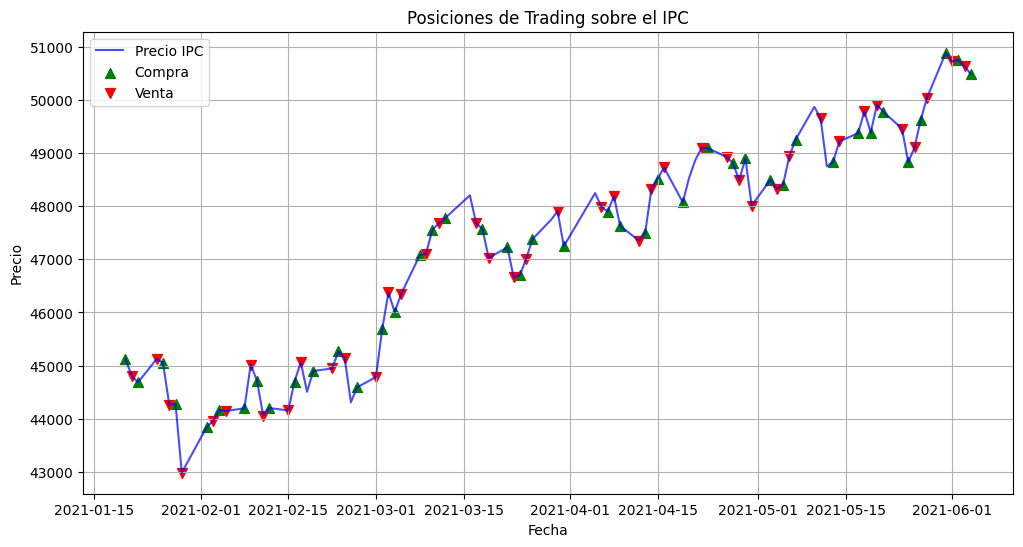

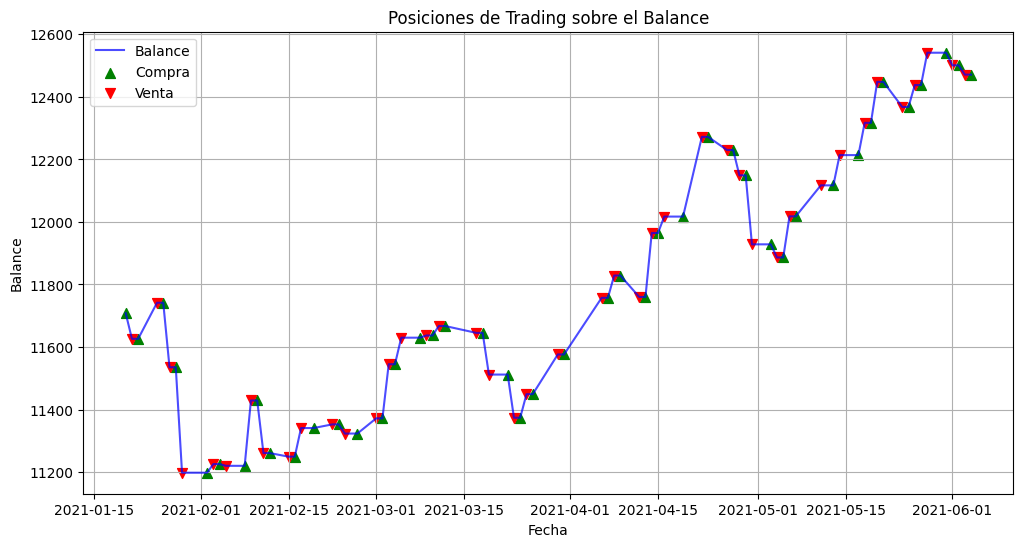

In [150]:
interval = slice("2021-01-20", "2021-06-04")  # Define el intervalo de fechas para filtrar
# Graficar las posiciones de trading sobre el IPC
plot_trading_positions(ipci_df[interval], trades_df[interval])
plot_trading_positionsb(trades_df[interval])
#plot_trading_positions(ipci_df, trades_df)
#plot_trading_positions(filter_ipci, filter_trades)

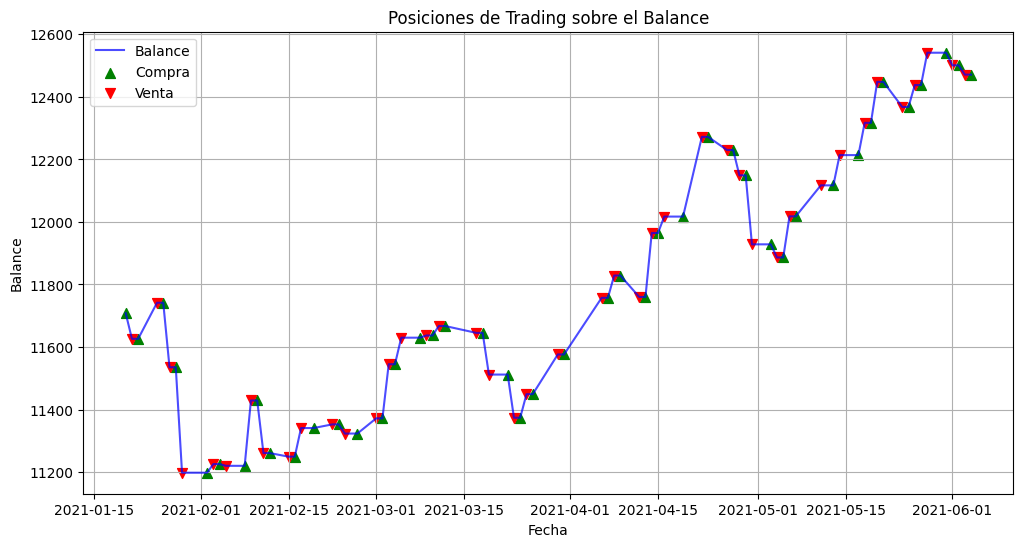

In [151]:
#buys,sells=
plot_trading_positionsb(trades_df[interval])

In [152]:
balans = trades_df[['Balance']].copy()
balans_logrets = np.log(balans / balans.shift(1)).dropna()
balans_rets = ((balans - balans.shift(1))/balans.shift(1)).dropna()
balans_rets

,Balance
Date,
2019-04-15,-0.001349
2019-04-16,0.000000
2019-04-17,0.011463
2019-04-22,0.000000
2019-04-23,-0.005132
...,...
2024-08-30,-0.004243
2024-09-02,0.000000
2024-09-03,-0.017220


In [153]:
balans_logrets

,Balance
Date,
2019-04-15,-0.001350
2019-04-16,0.000000
2019-04-17,0.011398
2019-04-22,0.000000
2019-04-23,-0.005145
...,...
2024-08-30,-0.004252
2024-09-02,0.000000
2024-09-03,-0.017370


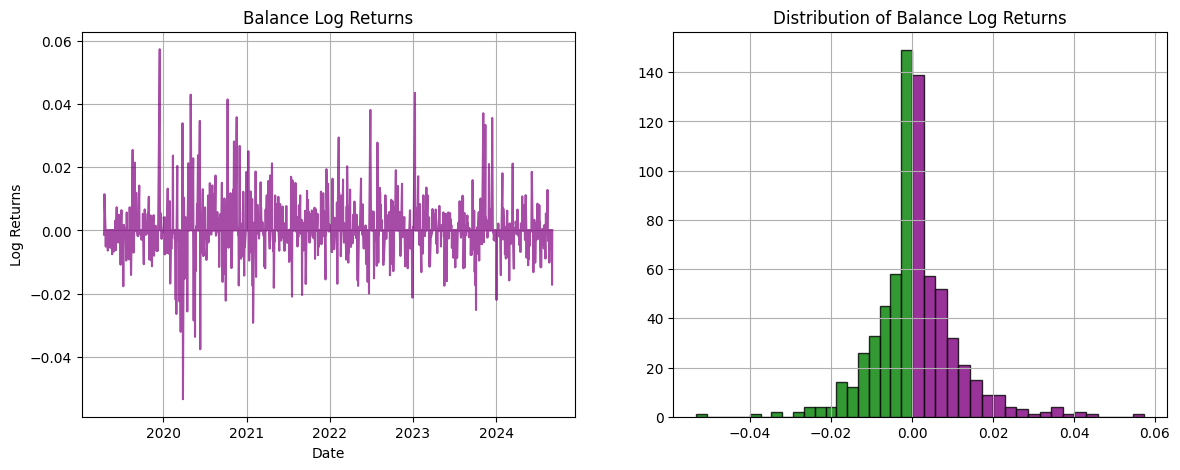

In [154]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
#balans_rets.plot( color='purple', alpha=0.7)
plt.plot(balans_rets.index, balans_rets, color='purple', alpha=0.7)
plt.title('Balance Log Returns')
plt.xlabel('Date')  
plt.ylabel('Log Returns')
plt.grid()

plt.subplot(1, 2, 2)
plt.hist(balans_rets[balans_logrets['Balance']<0], bins=20, alpha=0.8, edgecolor='black', color='green')#,orientation='horizontal')
plt.hist(balans_rets[balans_logrets['Balance']>0], bins=20, alpha=0.8, edgecolor='black', color='purple')#,orientation='horizontal')
#plt.hist(balans_rets, bins=30, alpha=0.8, edgecolor='black', color='purple')
plt.title('Distribution of Balance Log Returns')
plt.grid()
plt.show()

In [155]:
balans_logrets['Balance']

Date
2019-04-15   -0.001350
2019-04-16    0.000000
2019-04-17    0.011398
2019-04-22    0.000000
2019-04-23   -0.005145
                ...   
2024-08-30   -0.004252
2024-09-02    0.000000
2024-09-03   -0.017370
2024-09-04    0.000000
2024-09-04    0.000000
Name: Balance, Length: 1167, dtype: float64

array([[<Axes: title={'center': 'Balance'}>]], dtype=object)

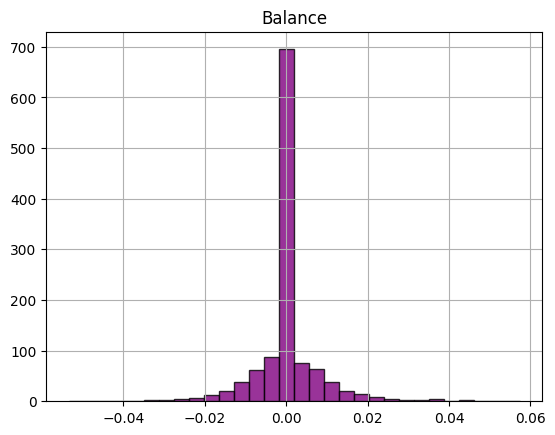

In [156]:
balans_rets.hist(bins=30, alpha=0.8, edgecolor='black', color='purple')

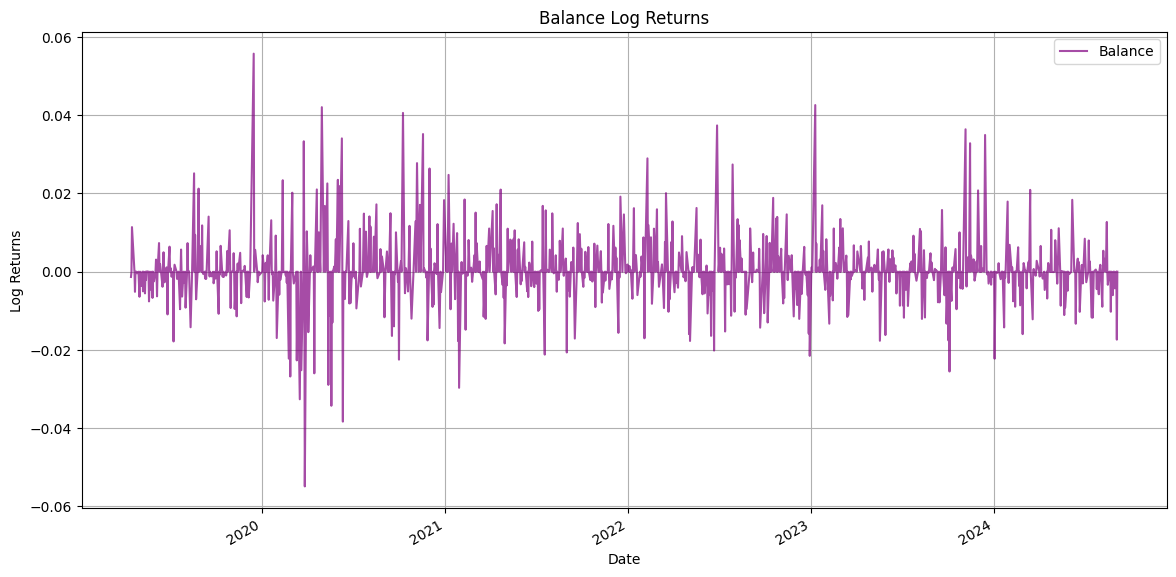

In [157]:
balans_logrets.plot(figsize=(14, 7), title='Balance Log Returns', color='purple', alpha=0.7)
plt.xlabel('Date')  
plt.ylabel('Log Returns')
plt.grid()
plt.show()

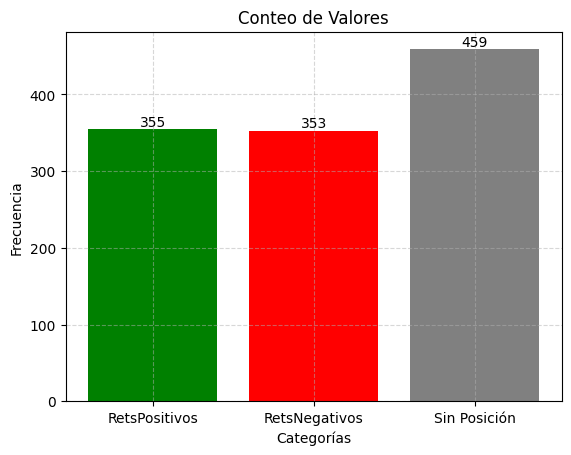

In [158]:
PosRets = (balans_logrets['Balance'] < 0).sum()# / len(balans_logrets) * 100
NegRets = (balans_logrets['Balance'] > 0).sum()# / len(balans_logrets) * 100
CeroRets = (balans_logrets['Balance'] == 0).sum()# / len(balans_logrets) * 100
conteos = [PosRets, NegRets, CeroRets]
categories = ['RetsPositivos', 'RetsNegativos', 'Sin Posición']  # Categorías de los retornos
# Porcentaje de días con retornos positivos en el balance
bars = plt.bar(categories, conteos, color=['green', 'red', 'gray'])
# Añadir texto con los valores de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, yval, ha='center', va='bottom')
plt.title('Conteo de Valores')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)  # Para que las etiquetas del eje x estén horizontales
plt.grid( linestyle='--', alpha=0.5)
plt.show()

In [159]:
PosRets = balans_logrets < 0
NegRets = (balans_logrets > 0)
CeroRets = (balans_logrets == 0)
PosRets

,Balance
Date,
2019-04-15,True
2019-04-16,False
2019-04-17,False
2019-04-22,False
2019-04-23,True
...,...
2024-08-30,True
2024-09-02,False
2024-09-03,True


In [160]:
balans_PosLRets = balans_logrets[balans_logrets['Balance']>0]
balans_NegLRets = balans_logrets[balans_logrets['Balance']<0]
balans_PosLRets.sum()+balans_NegLRets.sum()#, CeroRets.sum()

Balance    0.367727
dtype: float64

In [161]:
balans_PosRets = balans_rets[balans_rets['Balance']>0]
balans_NegRets = balans_rets[balans_rets['Balance']<0]
print(f'Rendimiento positivo -> {float(balans_PosRets.sum().iloc[0])*100}%')
print(f'Rendimiento negativo -> {balans_NegRets.sum().iloc[0]*100}%')
print(f'Rendimiento total -> {(balans_PosRets.sum()+balans_NegRets.sum()).iloc[0]*100} %')#, CeroRets.sum()

Rendimiento positivo -> 255.8817926755499%
Rendimiento negativo -> -215.35107330132251%
Rendimiento total -> 40.53071937422739 %


In [162]:
balans_PosRets['Balance']

Date
2019-04-17    1.146272e-02
2019-05-17    7.211402e-05
2019-06-04    3.094487e-03
2019-06-10    7.341973e-03
2019-06-12    1.978786e-03
                  ...     
2024-08-01    1.759347e-03
2024-08-07    5.367777e-03
2024-08-08    1.224604e-16
2024-08-09    3.309374e-03
2024-08-14    1.279399e-02
Name: Balance, Length: 353, dtype: float64

In [163]:
gg= np.sum(balans_NegRets, axis=0)
gg

Balance   -2.153511
dtype: float64

In [ ]:
def simulate_strategy(dpp, ipci_df, buy_threshold, sell_threshold, initial_balance=10000.0):
    """
    Simula la estrategia de trading usando los umbrales indicados.
    
    Parámetros:
      dpp: DataFrame que contiene el indicador "Daily Positive Percent" con índice de fecha.
      ipci_df: DataFrame que contiene el precio 'Close' del IPC, con índice de fecha.
      buy_threshold: Umbral para generar señal de compra.
      sell_threshold: Umbral para generar señal de venta.
      initial_balance: Balance inicial.
    
    Retorna:
      final_balance: Balance final tras aplicar la estrategia.
      trades: Lista de operaciones realizadas durante la simulación.
    """
    balance = initial_balance
    position = 0.0
    trades = []
    
    # Recorremos día a día
    for date, indicator in dpp['Daily Positive Percent'].items():
        try:
            price = ipci_df.loc[date, 'Close']
        except KeyError:
            continue  # Si no hay precio para esa fecha, se salta
        
        # Regla de entrada: si el indicador supera el umbral de compra y no se tiene posición abierta
        if indicator > buy_threshold and position == 0:
            position = balance / price
            balance = 0.0
            trades.append({'Date': date, 'Action': 'BUY', 'Price': price, 'Position': position})
        # Regla de salida: si el indicador cae por debajo del umbral de venta y se tiene posición abierta
        elif indicator < sell_threshold and position > 0:
            balance = position * price
            trades.append({'Date': date, 'Action': 'SELL', 'Price': price, 'Position': position})
            position = 0.0

    # Si al final sigue una posición abierta, la cerramos al último precio disponible
    if position > 0:
        final_date = dpp.index[-1]
        try:
            final_price = ipci_df.loc[final_date, 'Close']
        except KeyError:
            final_price = price
        balance = position * final_price
        trades.append({'Date': final_date, 'Action': 'SELL', 'Price': final_price, 'Position': position})
        position = 0.0

    return balance, trades



def optimize_thresholds(dpp, ipci_df, initial_balance=10000.0, buy_range=None, sell_range=None):
    """
    Busca los umbrales óptimos para la estrategia, probando distintos pares (buy_threshold, sell_threshold)
    y selecciona el par que maximiza el balance final.
    
    Parámetros:
      dpp: DataFrame que contiene el indicador "Daily Positive Percent".
      ipci_df: DataFrame que contiene los precios del IPC en la columna 'Close'.
      initial_balance: Balance inicial para la simulación.
      buy_range: Rango de valores candidatos para el umbral de compra.
      sell_range: Rango de valores candidatos para el umbral de venta.
    
    Retorna:
      best_thresholds: Tuple (buy_threshold, sell_threshold) que producen el mejor balance.
      results: Lista de diccionarios con los resultados de cada par probado.
    """
    # Definir rangos por defecto si no se proporcionan.
    if buy_range is None:
        buy_range = range(50, 101, 5)  # Por ejemplo, de 50 a 100
    if sell_range is None:
        sell_range = range(0, 51, 5)    # Por ejemplo, de 0 a 50

    best_balance = -float('inf')
    best_thresholds = (None, None)
    results = []

    # Recorrer todas las combinaciones de umbrales.
    for buy_threshold in buy_range:
        for sell_threshold in sell_range:
            # Para esta estrategia se asume que comprar se activa con un indicador alto,
            # mientras que vender se activa con un indicador bajo: require buy_threshold > sell_threshold
            if sell_threshold >= buy_threshold:
                continue

            final_balance, _ = simulate_strategy(dpp, ipci_df, buy_threshold, sell_threshold, initial_balance)
            trading_return = (final_balance - initial_balance) / initial_balance * 100
            results.append({
                'buy_threshold': buy_threshold,
                'sell_threshold': sell_threshold,
                'final_balance': final_balance,
                'trading_return_percentage': trading_return
            })

            if final_balance > best_balance:
                best_balance = final_balance
                best_thresholds = (buy_threshold, sell_threshold)

    return best_thresholds, results